In [1]:
import subprocess, sys

def pip(*args):
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args],
                       capture_output=True, text=True)
    status = "OK" if r.returncode == 0 else f"WARN: {r.stderr[-150:].strip()}"
    print(f"  {' '.join(args[:2]):<40s} {status}")
pip("bitsandbytes==0.42.0")
pip("transformers==4.44.2")
pip("accelerate==0.33.0")
pip("diffusers==0.30.3")
pip("controlnet_aux==0.0.9")
pip("ezdxf==1.3.4")
pip("huggingface_hub==0.24.7")
print("  xformers (cu118)                         ", end="")
r = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "xformers", "--index-url", "https://download.pytorch.org/whl/cu118"],
    capture_output=True, text=True
)
print("OK" if r.returncode == 0 else f"WARN: {r.stderr[-100:].strip()}")

  bitsandbytes==0.42.0                     OK
  transformers==4.44.2                     OK
  accelerate==0.33.0                       OK
  diffusers==0.30.3                        OK
  controlnet_aux==0.0.9                    OK
  ezdxf==1.3.4                             OK
  huggingface_hub==0.24.7                  OK
  xformers (cu118)                         OK


In [3]:
!pip install --force-reinstall -v "triton==3.1.0"

Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
  Obtaining dependency information for triton==3.1.0 from https://files.pythonhosted.org/packages/78/eb/65f5ba83c2a123f6498a3097746607e5b2f16add29e36765305e4ac7fdd8/triton-3.1.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Obtaining dependency information for filelock from https://files.pythonhosted.org/packages/a4/a5/842ae8f0c08b61d6484b52f99a03510a3a72d23141942d216ebe81fefbce/filelock-3.25.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 MB 5.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: filelock
    Found existing installation: filelock 3.24.3
    Uninstalling filelock-3.24.3:
      Removing file or directory /usr/local/lib/python3.12/dist-packages/filelock-3.24.3.dist-info/
      Removing file or directory /usr/local/lib/python3.12/dist-packages/filelock/
      Successfully uninstalled filelock-3.24.3
  Attempting uninstall: triton
    

In [1]:
import os, gc, re, json, math, time, warnings
from pathlib import Path
from typing import Optional, Tuple, List

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as mpe
from PIL import Image, ImageDraw

warnings.filterwarnings('ignore')

if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: Khong co GPU')

try:
    from kaggle_secrets import UserSecretsClient
    _token = UserSecretsClient().get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(token=_token, add_to_git_credential=False)
    print('dang nhap thanh cong.')
except Exception:
    print('khong co HF_TOKEN')

OUTPUT_DIR = Path('/kaggle/working/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')

GPU : Tesla T4
VRAM: 15.6 GB
khong co HF_TOKEN
Output dir: /kaggle/working/output


In [2]:
VALID_ORIENTATIONS = ['N', 'S', 'E', 'W', 'NE', 'NW', 'SE', 'SW']


class RoomSpecParser:
    """
    Parse room spec tu file .json / .txt hoac dict inline.
    Truong bat buoc: length, width, height, function, style.
    """
    REQUIRED = {'length', 'width', 'height', 'function', 'style'}
    DEFAULTS  = {'windows': 1, 'doors': 1, 'orientation': 'N', 'budget': 'mid', 'notes': ''}

    def parse_file(self, filepath):
        path = Path(filepath)
        if not path.exists():
            raise FileNotFoundError(f'Khong tim thay: {filepath}')
        if path.suffix.lower() == '.json':
            with open(path, encoding='utf-8') as f:
                raw = json.load(f)
        elif path.suffix.lower() in ('.txt', '.text'):
            raw = {}
            with open(path, encoding='utf-8') as f:
                for ln, line in enumerate(f, 1):
                    line = line.strip()
                    if not line or line.startswith('#') or ':' not in line:
                        continue
                    k, _, v = line.partition(':')
                    raw[k.strip().lower()] = v.strip()
        else:
            raise ValueError(f'Chi ho tro .json / .txt')
        return self._normalize(raw)

    def parse_dict(self, data):
        return self._normalize(data)

    def _normalize(self, raw):
        raw = {k.lower().strip(): v for k, v in raw.items()}
        missing = self.REQUIRED - raw.keys()
        if missing:
            raise ValueError(f'Thieu truong bat buoc: {missing}')
        spec = dict(self.DEFAULTS)
        spec.update(raw)
        for field in ('length', 'width', 'height'):
            spec[field] = float(spec[field])
            if spec[field] <= 0:
                raise ValueError(f'`{field}` phai > 0')
        for field in ('windows', 'doors'):
            spec[field] = int(spec[field])
        if not (1.5 <= spec['length'] <= 50):
            raise ValueError(f'length phai 1.5-50m')
        if not (1.5 <= spec['width'] <= 50):
            raise ValueError(f'width phai 1.5-50m')
        if not (2.0 <= spec['height'] <= 6.0):
            raise ValueError(f'height phai 2-6m')
        spec['function']    = str(spec['function']).strip().lower()
        spec['style']       = str(spec['style']).strip().lower()
        spec['budget']      = str(spec['budget']).strip().lower()
        spec['orientation'] = str(spec['orientation']).strip().upper()
        if spec['orientation'] not in VALID_ORIENTATIONS:
            spec['orientation'] = 'N'
        spec['area_m2'] = round(spec['length'] * spec['width'], 2)
        return spec


parser = RoomSpecParser()

In [3]:
room_spec = parser.parse_dict({
    'length'     : 6.0,
    'width'      : 4.5,
    'height'     : 2.7,
    'function'   : 'phong khach',
    'style'      : 'scandinavian',
    'windows'    : 2,
    'doors'      : 1,
    'orientation': 'S',
    'budget'     : 'mid',
    'notes'      : 'Cua so lon huong Nam',
})

# De dung tieng Viet co dau, dung parse_file():
# room_spec = parser.parse_file('/kaggle/working/output/room_spec.json')

print(json.dumps(room_spec, ensure_ascii=False, indent=2))

{
  "windows": 2,
  "doors": 1,
  "orientation": "S",
  "budget": "mid",
  "notes": "Cua so lon huong Nam",
  "length": 6.0,
  "width": 4.5,
  "height": 2.7,
  "function": "phong khach",
  "style": "scandinavian",
  "area_m2": 27.0
}


In [4]:
import sys, torch

for _k in list(sys.modules.keys()):
    if 'torchvision' in _k:
        del sys.modules[_k]

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import transformers
print(f"transformers : {transformers.__version__}")

import bitsandbytes as bnb
print(f"bitsandbytes : {bnb.__version__}")

assert torch.cuda.is_available(), "Không có GPU"
print(f"GPU          : {torch.cuda.get_device_name(0)}")
print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

LLM_MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

print(f"\nLoading {LLM_MODEL_ID} (4-bit NF4)...")

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID)

llm = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_ID,
    quantization_config=bnb_cfg,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",  
)
llm.eval()

print(f"\nModel ready. VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB")

transformers : 4.44.2
bitsandbytes : 0.42.0
GPU          : Tesla T4
VRAM         : 15.6 GB

Loading mistralai/Mistral-7B-Instruct-v0.3 (4-bit NF4)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]


Model ready. VRAM used: 2.4 GB


In [5]:
ROOM_TEMPLATES = {
    'phong khach': [
        {'name': 'sofa',         'name_vi': 'ghe sofa',       'w': 2.2,  'l': 0.9,  'h': 0.85},
        {'name': 'coffee table', 'name_vi': 'ban tra',         'w': 1.1,  'l': 0.6,  'h': 0.45},
        {'name': 'tv stand',     'name_vi': 'ke tivi',         'w': 1.6,  'l': 0.4,  'h': 0.5 },
        {'name': 'armchair',     'name_vi': 'ghe banh',        'w': 0.8,  'l': 0.8,  'h': 0.85},
        {'name': 'armchair',     'name_vi': 'ghe banh',        'w': 0.8,  'l': 0.8,  'h': 0.85},
        {'name': 'side table',   'name_vi': 'ban phu',         'w': 0.5,  'l': 0.5,  'h': 0.55},
        {'name': 'floor lamp',   'name_vi': 'den san',         'w': 0.3,  'l': 0.3,  'h': 1.6 },
        {'name': 'rug',          'name_vi': 'tham',            'w': 2.0,  'l': 1.4,  'h': 0.01},
    ],
    'phong ngu': [
        {'name': 'double bed',   'name_vi': 'giuong doi',      'w': 1.6,  'l': 2.0,  'h': 0.5 },
        {'name': 'nightstand',   'name_vi': 'tu dau giuong',   'w': 0.5,  'l': 0.45, 'h': 0.55},
        {'name': 'nightstand',   'name_vi': 'tu dau giuong',   'w': 0.5,  'l': 0.45, 'h': 0.55},
        {'name': 'wardrobe',     'name_vi': 'tu quan ao',      'w': 1.8,  'l': 0.6,  'h': 2.0 },
        {'name': 'dresser',      'name_vi': 'tu ngan keo',     'w': 1.0,  'l': 0.45, 'h': 0.85},
        {'name': 'lounge chair', 'name_vi': 'ghe thu gian',    'w': 0.75, 'l': 0.8,  'h': 0.8 },
    ],
    'phong lam viec': [
        {'name': 'desk',         'name_vi': 'ban lam viec',    'w': 1.4,  'l': 0.7,  'h': 0.75},
        {'name': 'office chair', 'name_vi': 'ghe van phong',   'w': 0.65, 'l': 0.65, 'h': 1.1 },
        {'name': 'bookshelf',    'name_vi': 'ke sach',         'w': 0.8,  'l': 0.3,  'h': 2.0 },
        {'name': 'bookshelf',    'name_vi': 'ke sach',         'w': 0.8,  'l': 0.3,  'h': 2.0 },
        {'name': 'lounge chair', 'name_vi': 'ghe phu',         'w': 0.75, 'l': 0.8,  'h': 0.8 },
    ],
    'phong an': [
        {'name': 'dining table', 'name_vi': 'ban an',          'w': 1.6,  'l': 0.9,  'h': 0.75},
        {'name': 'dining chair', 'name_vi': 'ghe an',          'w': 0.45, 'l': 0.45, 'h': 0.9 },
        {'name': 'dining chair', 'name_vi': 'ghe an',          'w': 0.45, 'l': 0.45, 'h': 0.9 },
        {'name': 'dining chair', 'name_vi': 'ghe an',          'w': 0.45, 'l': 0.45, 'h': 0.9 },
        {'name': 'dining chair', 'name_vi': 'ghe an',          'w': 0.45, 'l': 0.45, 'h': 0.9 },
        {'name': 'sideboard',    'name_vi': 'tu bep thap',     'w': 1.4,  'l': 0.45, 'h': 0.85},
    ],
}

FUNC_ALIAS = {
    'phong khach'   : 'phong khach',
    'living room'   : 'phong khach',
    'phong ngu'     : 'phong ngu',
    'bedroom'       : 'phong ngu',
    'phong lam viec': 'phong lam viec',
    'home office'   : 'phong lam viec',
    'phong an'      : 'phong an',
    'dining room'   : 'phong an',
}

MUST_HAVE = {
    'phong khach'   : ['sofa'],
    'phong ngu'     : ['double bed'],
    'phong lam viec': ['desk', 'office chair'],
    'phong an'      : ['dining table'],
}

WALL_GAP = 0.05
ITEM_GAP = 0.06

def get_effective_dims(item):
    w = float(item.get('w', 0.5))
    l = float(item.get('l', 0.5))
    rot = float(item.get('rotation', 0))
    if round(rot) % 180 == 90:
        return l, w
    return w, l

def get_item_center(item):
    x = float(item.get('x', 0))
    y = float(item.get('y', 0))
    w = float(item.get('w', 0.5))
    l = float(item.get('l', 0.5))
    return x + w / 2.0, y + l / 2.0

def set_item_center(item, cx, cy):
    w = float(item.get('w', 0.5))
    l = float(item.get('l', 0.5))
    item['x'] = round(cx - w / 2.0, 2)
    item['y'] = round(cy - l / 2.0, 2)

def get_rotated_corners(cx, cy, w, l, rot_deg):
    rad = math.radians(rot_deg)
    cos_r, sin_r = math.cos(rad), math.sin(rad)
    local_corners = [
        (-w / 2.0, -l / 2.0),
        (w / 2.0, -l / 2.0),
        (w / 2.0, l / 2.0),
        (-w / 2.0, l / 2.0),
    ]
    rotated = []
    for lx, ly in local_corners:
        rx = cx + lx * cos_r - ly * sin_r
        ry = cy + lx * sin_r + ly * cos_r
        rotated.append((rx, ry))
    return rotated

def _overlaps(a, b, gap=ITEM_GAP):
    name_a = (a.get('name_vi') or a.get('name', '')).lower()
    name_b = (b.get('name_vi') or b.get('name', '')).lower()
    exceptions = ['rug', 'tham', 'den san', 'floor lamp', 'ceiling lamp', 'den tran', 'den chum', 'painting', 'tranh']
    if any(ex in name_a for ex in exceptions) or any(ex in name_b for ex in exceptions):
        return False
        
    aw, al = get_effective_dims(a)
    bw, bl = get_effective_dims(b)
    acx, acy = get_item_center(a)
    bcx, bcy = get_item_center(b)
    
    ax_min, ax_max = acx - aw / 2.0, acx + aw / 2.0
    ay_min, ay_max = acy - al / 2.0, acy + al / 2.0
    bx_min, bx_max = bcx - bw / 2.0, bcx + bw / 2.0
    by_min, by_max = bcy - bl / 2.0, bcy + bl / 2.0
    
    return (
        ax_min - gap < bx_max and
        ax_max + gap > bx_min and
        ay_min - gap < by_max and
        ay_max + gap > by_min
    )

def _clamp(item, W, L):
    c = dict(item)
    ew, el = get_effective_dims(c)
    cx, cy = get_item_center(c)
    cx = max(WALL_GAP + ew / 2.0, min(cx, W - WALL_GAP - ew / 2.0))
    cy = max(WALL_GAP + el / 2.0, min(cy, L - WALL_GAP - el / 2.0))
    set_item_center(c, cx, cy)
    return c

def _find_free_spiral(item, placed, W, L):
    ew, el = get_effective_dims(item)
    orig_cx, orig_cy = get_item_center(item)
    step = 0.1
    x_steps = int(W / step)
    y_steps = int(L / step)
    candidates = []
    for j in range(y_steps + 1):
        cy = round(j * step, 2)
        if cy < WALL_GAP + el / 2.0 or cy > L - WALL_GAP - el / 2.0:
            continue
        for i in range(x_steps + 1):
            cx = round(i * step, 2)
            if cx < WALL_GAP + ew / 2.0 or cx > W - WALL_GAP - ew / 2.0:
                continue
            dist = math.hypot(cx - orig_cx, cy - orig_cy)
            candidates.append((dist, cx, cy))
            
    candidates.sort(key=lambda x: x[0])
    for dist, cx, cy in candidates:
        cand = dict(item)
        set_item_center(cand, cx, cy)
        if not any(_overlaps(cand, p) for p in placed):
            return cand
    return None

def auto_layout(furniture, W, L):
    placed = []
    for item in furniture:
        item = _clamp(item, W, L)
        if any(_overlaps(item, p) for p in placed):
            fixed = _find_free_spiral(item, placed, W, L)
            if fixed is None:
                n = item.get('name_vi', item.get('name', '?'))
                print(f'    [skip] het cho: {n}')
                continue
            item = fixed
        placed.append(item)
    return placed

def _get_template_key(spec):
    func = spec['function'].lower()
    if func in ROOM_TEMPLATES:
        return func
    for alias, key in FUNC_ALIAS.items():
        if alias in func or func in alias:
            return key
    return 'phong khach'  

def ensure_must_have(furniture, spec):
    tkey     = _get_template_key(spec)
    template = ROOM_TEMPLATES.get(tkey, [])
    existing = {it['name'].lower() for it in furniture}
    for must in MUST_HAVE.get(tkey, []):
        if not any(must in n for n in existing):
            tmpl = next((t for t in template if must in t['name']), None)
            if tmpl:
                added = dict(tmpl)
                added.update({'x': 0.0, 'y': 0.0, 'rotation': 0,
                               'material': 'wood', 'color': 'natural'})
                print(f"    [bo sung] '{tmpl['name_vi']}' bi LLM bo sot")
                furniture.insert(0, added)
    return furniture

def _fallback_layout(spec):
    tkey  = _get_template_key(spec)
    items = ROOM_TEMPLATES.get(tkey, ROOM_TEMPLATES['phong khach'])
    return {
        'furniture': [
            dict(t, x=0.0, y=0.0, rotation=0, material='wood', color='natural')
            for t in items
        ],
        'style_description': f'{spec["style"]} interior design',
        'color_palette': ['#F5F0E8', '#D4C5B0', '#8B7355'],
        'materials': ['wood', 'fabric'],
        'lighting': 'Natural daylight',
        'image_prompt_keywords': f'{spec["style"]} {spec["function"]}',
    }

In [6]:
SYSTEM_PROMPT = (
    'Ban la chuyen gia thiet ke noi that. '
    'Tra ve JSON hop le DUY NHAT, khong co text nao khac.\n\n'
    'QUY TAC TOA DO:\n'
    '- Goc goc (0,0) = goc duoi-trai phong\n'
    '- x tang sang phai (max=width), y tang len tren (max=length)\n'
    '- Do sat tuong truoc: y=0.1  |  sat tuong sau: y=length-l-0.1\n'
    '- KHONG de do chong nhau. KHONG de do vuot tuong.\n\n'
    'PHONG KHACH BAT BUOC: sofa, coffee table, tv stand, armchair\n'
    'PHONG NGU BAT BUOC: double bed, 2x nightstand, wardrobe\n'
    'PHONG LAM VIEC BAT BUOC: desk, office chair, bookshelf\n\n'
    'JSON SCHEMA:\n'
    '{"furniture":[{"name":"EN","name_vi":"VI","w":0.0,"l":0.0,"h":0.0,'
    '"x":0.0,"y":0.0,"rotation":0,"material":"...","color":"..."}],'
    '"style_description":"...","color_palette":["#hex"],'
    '"materials":["..."],"lighting":"...","image_prompt_keywords":"..."}'
)

FEW_SHOT = (
    'INPUT: {"length":6.0,"width":4.5,"height":2.7,"function":"phong khach",'
    '"style":"scandinavian","windows":2,"doors":1,"budget":"mid"}\n\n'
    'OUTPUT: {"furniture":['
    '{"name":"sofa","name_vi":"ghe sofa","w":2.2,"l":0.9,"h":0.85,"x":1.05,"y":0.1,"rotation":0,"material":"linen","color":"light gray"},'
    '{"name":"coffee table","name_vi":"ban tra","w":1.1,"l":0.6,"h":0.45,"x":1.35,"y":1.15,"rotation":0,"material":"oak","color":"natural oak"},'
    '{"name":"tv stand","name_vi":"ke tivi","w":1.6,"l":0.4,"h":0.5,"x":1.45,"y":5.5,"rotation":0,"material":"oak","color":"white oak"},'
    '{"name":"armchair","name_vi":"ghe banh","w":0.8,"l":0.8,"h":0.85,"x":0.1,"y":1.0,"rotation":0,"material":"wool","color":"beige"},'
    '{"name":"armchair","name_vi":"ghe banh","w":0.8,"l":0.8,"h":0.85,"x":3.6,"y":1.0,"rotation":0,"material":"wool","color":"beige"},'
    '{"name":"side table","name_vi":"ban phu","w":0.45,"l":0.45,"h":0.55,"x":0.1,"y":2.0,"rotation":0,"material":"oak","color":"natural"},'
    '{"name":"floor lamp","name_vi":"den san","w":0.3,"l":0.3,"h":1.6,"x":3.85,"y":2.1,"rotation":0,"material":"metal","color":"matte black"},'
    '{"name":"rug","name_vi":"tham","w":2.0,"l":1.4,"h":0.01,"x":1.1,"y":0.9,"rotation":0,"material":"wool","color":"cream"}'
    '],\n'
    '"style_description":"Scandinavian toi gian, go sang, vai linen, tong mau trung tinh.",\n'
    '"color_palette":["#F5F0E8","#D4C5B0","#8B7355","#3D3B38"],\n'
    '"materials":["linen","oak wood","wool"],\n'
    '"lighting":"Den tran 3000K + den san goc phong",\n'
    '"image_prompt_keywords":"scandinavian living room, linen sofa, oak coffee table, white walls, hygge, natural light"}'
)


def _extract_json(text):
    text = re.sub(r'^```(?:json)?\n?', '', text.strip())
    text = re.sub(r'\n?```$', '', text).strip()
    m = re.search(r'\{.*\}', text, re.DOTALL)
    return m.group(0) if m else text


@torch.no_grad()
def consult_llm(spec, max_new_tokens=1600, max_retries=2):
    W, L = spec['width'], spec['length']
    user_msg = json.dumps({
        'length': L, 'width': W, 'height': spec['height'],
        'function': spec['function'], 'style': spec['style'],
        'windows': spec['windows'], 'doors': spec['doors'],
        'budget': spec.get('budget', 'mid'),
    }, ensure_ascii=False)

    # Use apply_chat_template for model compatibility
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Vi du:\n{FEW_SHOT}\n\nPhong can tu van:\n{user_msg}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    enc            = tokenizer(prompt, return_tensors='pt')
    input_ids      = enc['input_ids'].to(llm.device)
    attention_mask = enc['attention_mask'].to(llm.device)
    prompt_len     = input_ids.shape[-1]
    print(f'Prompt tokens: {prompt_len}')

    layout = None
    for attempt in range(max_retries + 1):
        temp = 0.25 + attempt * 0.15
        print(f'  Lan {attempt+1}/{max_retries+1} | temp={temp:.2f} | generating...')
        out_ids = llm.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            temperature=temp,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        gen_ids  = out_ids[0][prompt_len:]
        raw_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
        print(f'  Raw ({len(raw_text)} chars): {raw_text[:100].replace(chr(10)," ")}...')
        try:
            layout = json.loads(_extract_json(raw_text))
            if 'furniture' not in layout or not isinstance(layout['furniture'], list):
                raise ValueError('thieu key furniture')
            print(f'  JSON OK - {len(layout["furniture"])} mon tu LLM')
            break
        except (json.JSONDecodeError, ValueError) as e:
            print(f'  [parse error] {e}')
            if attempt == max_retries:
                print('  -> Dung fallback template')
                layout = _fallback_layout(spec)

    print('  [post-process] bo sung do bi thieu + sap xep lai...')
    layout['furniture'] = ensure_must_have(layout['furniture'], spec)
    layout['furniture'] = auto_layout(layout['furniture'], W, L)
    print(f'  Ket qua: {len(layout["furniture"])} mon, khong overlap.')
    return layout

In [7]:
layout = consult_llm(room_spec)

print('\n-- Danh sach noi that --')
for i, it in enumerate(layout['furniture'], 1):
    nm = it.get('name_vi', it.get('name', '?'))
    print(f"  {i:2}. {nm:22s}  {it['w']:.1f}x{it['l']:.1f}x{it['h']:.1f}m  @ ({it['x']:.2f}, {it['y']:.2f})")

print(f"\nPhong cach: {layout.get('style_description','')[:80]}")
print(f"Palette   : {layout.get('color_palette',[])}")
print(f"Vat lieu  : {layout.get('materials',[])}")

layout_path = OUTPUT_DIR / 'layout.json'
with open(layout_path, 'w', encoding='utf-8') as f:
    json.dump(layout, f, ensure_ascii=False, indent=2)
print(f'\nLayout saved: {layout_path}')

Prompt tokens: 1075
  Lan 1/3 | temp=0.25 | generating...


2026-03-25 02:17:56.582264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774405077.035402     171 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774405077.155768     171 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774405078.196998     171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774405078.197031     171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774405078.197034     171 computation_placer.cc:177] computation placer alr

  Raw (2217 chars): Output:  ```json {   "furniture": [     {       "name": "sofa",       "name_vi": "ghe sofa",       "...
  JSON OK - 8 mon tu LLM
  [post-process] bo sung do bi thieu + sap xep lai...
  Ket qua: 8 mon, khong overlap.

-- Danh sach noi that --
   1. ghe sofa                2.2x0.9x0.8m  @ (1.05, 0.10)
   2. ban tra                 1.1x0.6x0.5m  @ (1.35, 1.15)
   3. ke tivi                 1.6x0.4x0.5m  @ (1.45, 5.50)
   4. ghe banh                0.8x0.8x0.8m  @ (0.10, 1.00)
   5. ghe banh                0.8x0.8x0.8m  @ (3.60, 1.00)
   6. ban phu                 0.5x0.5x0.6m  @ (0.10, 2.00)
   7. den san                 0.3x0.3x1.6m  @ (3.85, 2.10)
   8. tham                    2.0x1.4x0.0m  @ (0.70, 1.90)

Phong cach: Scandinavian living room with a focus on linen, overall neutral color palette.
Palette   : ['#F5F0E8', '#D4C5B0', '#8B7355', '#3D3B38']
Vat lieu  : ['linen', 'oak wood', 'wool']

Layout saved: /kaggle/working/output/layout.json


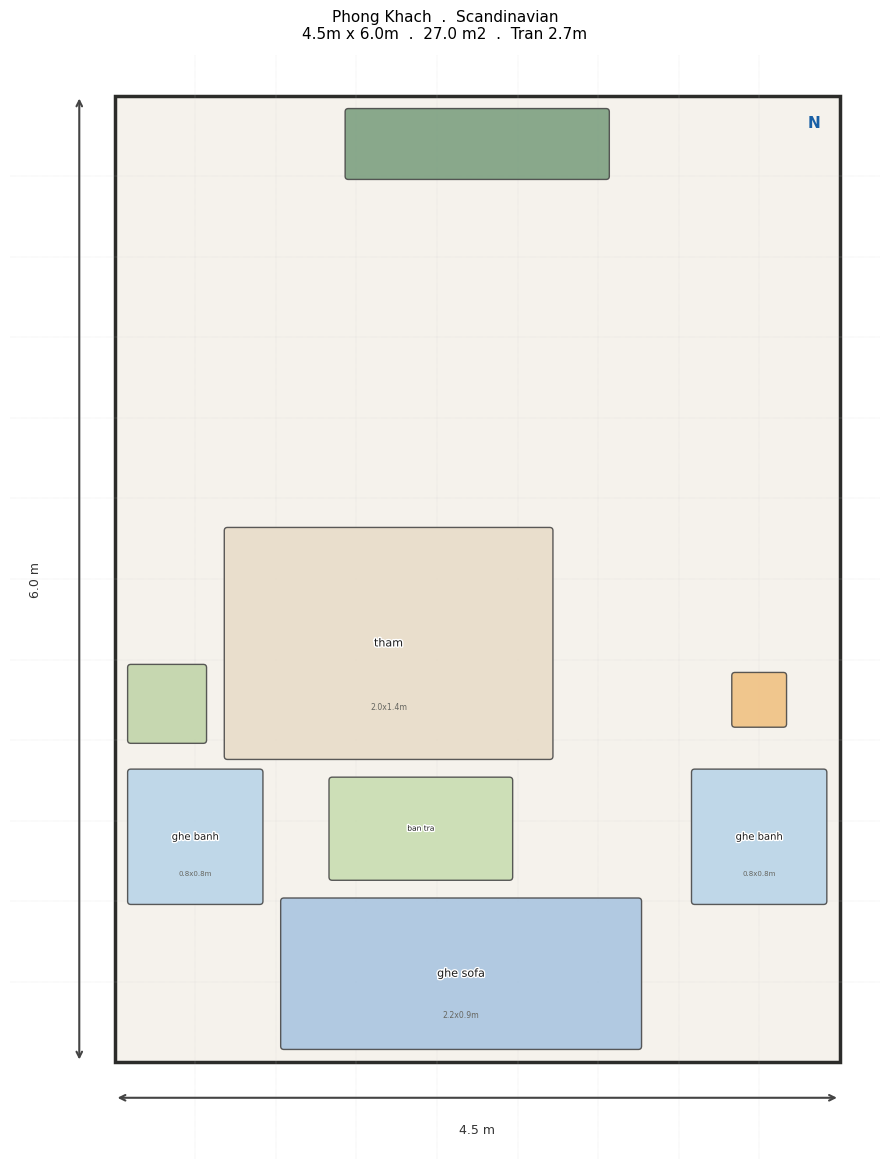

Floor plan: /kaggle/working/output/floor_plan_preview.png  |  8 mon do


In [8]:
COLOR_MAP = {
    'sofa':'#A8C4E0',         'ghe sofa':'#A8C4E0',
    'coffee table':'#C8DDB0', 'ban tra':'#C8DDB0',
    'tv stand':'#7A9E7E',     'ke tivi':'#7A9E7E',
    'armchair':'#B8D4E8',     'ghe banh':'#B8D4E8',
    'rug':'#E8DCC8',          'tham':'#E8DCC8',
    'floor lamp':'#F0C080',   'den san':'#F0C080',
    'bookshelf':'#D4A890',    'ke sach':'#D4A890',
    'side table':'#C0D4A8',   'ban phu':'#C0D4A8',
    'double bed':'#A8B8E0',   'giuong doi':'#A8B8E0',
    'wardrobe':'#C8A8D0',     'tu quan ao':'#C8A8D0',
    'nightstand':'#D0C8A8',   'tu dau giuong':'#D0C8A8',
    'desk':'#A8D0C8',         'ban lam viec':'#A8D0C8',
    'dining table':'#E0C898', 'ban an':'#E0C898',
    'dining chair':'#C8D4A8', 'ghe an':'#C8D4A8',
}
FB_COLORS = ['#B8C8D8','#C8D8B8','#D8C8B8','#C8B8D8','#D8D8B8','#B8D8C8','#D8B8C8']

def _item_color(item, idx):
    nm = item.get('name_vi', item.get('name', '')).lower()
    for k, v in COLOR_MAP.items():
        if k in nm:
            return v
    return FB_COLORS[idx % len(FB_COLORS)]

W = room_spec['width']
L = room_spec['length']
fig, ax = plt.subplots(figsize=(9, max(6.0, 9.0 * L / W)))
ax.set_facecolor('#FAFAF7')
fig.patch.set_facecolor('#FFFFFF')

ax.add_patch(mpatches.Rectangle(
    (0, 0), W, L, facecolor='#F5F2EC', edgecolor='#2C2C2A', linewidth=2.5, zorder=1
))
for xg in np.arange(0.5, W, 0.5):
    ax.axvline(xg, color='#CCCCCC', lw=0.3, ls=':')
for yg in np.arange(0.5, L, 0.5):
    ax.axhline(yg, color='#CCCCCC', lw=0.3, ls=':')

for idx, item in enumerate(layout.get('furniture', [])):
    cx, cy = get_item_center(item)
    w,  ld = float(item.get('w', 0.5)), float(item.get('l', 0.5))
    rot    = float(item.get('rotation', 0))
    nm     = item.get('name_vi') or item.get('name', '')
    col    = _item_color(item, idx)
    
    # Draw rotated bounding box using Polygon
    corners = get_rotated_corners(cx, cy, w, ld, rot)
    ax.add_patch(mpatches.Polygon(
        corners, closed=True,
        facecolor=col, edgecolor='#444444', lw=1.0, alpha=0.88, zorder=2
    ))
    
    fs = min(8.0, w * 9, ld * 9)
    if fs >= 5.0 and w >= 0.3 and ld >= 0.25:
        ax.text(cx, cy, nm, ha='center', va='center', fontsize=fs,
                color='#1A1A1A',
                path_effects=[mpe.withStroke(linewidth=2, foreground='white')], zorder=3)
    if fs >= 6.0 and ld >= 0.4:
        ax.text(cx, cy - ld*0.22, f'{w:.1f}x{ld:.1f}m', ha='center', va='center',
                fontsize=fs*0.7, color='#666660', zorder=3)

ax.annotate('', xy=(W,-0.22), xytext=(0,-0.22),
            arrowprops=dict(arrowstyle='<->', color='#444', lw=1.5))
ax.text(W/2, -0.38, f'{W:.1f} m', ha='center', va='top', fontsize=9, color='#333')
ax.annotate('', xy=(-0.22,L), xytext=(-0.22,0),
            arrowprops=dict(arrowstyle='<->', color='#444', lw=1.5))
ax.text(-0.45, L/2, f'{L:.1f} m', ha='right', va='center', fontsize=9, color='#333', rotation=90)
ax.text(W-0.12, L-0.12, 'N', ha='right', va='top', fontsize=11, color='#185FA5', fontweight='bold')

ax.set_xlim(-0.65, W+0.25)
ax.set_ylim(-0.6, L+0.25)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    f"{room_spec['function'].title()}  .  {room_spec['style'].title()}\n"
    f"{W}m x {L}m  .  {room_spec['area_m2']:.1f} m2  .  Trần {room_spec['height']}m",
    fontsize=11, pad=12
)
plt.tight_layout()
preview_path = OUTPUT_DIR / 'floor_plan_preview.png'
plt.savefig(preview_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Floor plan: {preview_path}  |  {len(layout["furniture"])} mon do')

In [9]:
import ezdxf
from ezdxf.enums import TextEntityAlignment

LAYER_COLORS = {
    'WALL':8, 'FLOOR':9, 'CEILING':254,
    'BED':4, 'SOFA':5, 'TABLE':2, 'CHAIR':3,
    'WARDROBE':6, 'CABINET':7, 'DESK':30,
    'LAMP':40, 'RUG':50, 'SHELF':60, 'DEFAULT':1,
}

def _layer_name(name):
    u = name.upper().replace(' ', '_').replace('-', '_')
    for k in LAYER_COLORS:
        if k in u:
            return k
    return u

def _ensure_layer(doc, name, color=None):
    c = color if color is not None else LAYER_COLORS.get(name, LAYER_COLORS['DEFAULT'])
    if name not in doc.layers:
        doc.layers.add(name, dxfattribs={'color': c})
    else:
        doc.layers.get(name).dxf.color = c

def _add_box(msp, x, y, z, w, l, h, layer, rot_deg=0.0):
    """6-face solid box using 3DFACE entities."""
    pts = [
        (x,   y,   z),   (x+w, y,   z),   (x+w, y+l, z),   (x,   y+l, z),
        (x,   y,   z+h), (x+w, y,   z+h), (x+w, y+l, z+h), (x,   y+l, z+h),
    ]
    if rot_deg % 360 != 0:
        cx, cy = x + w/2, y + l/2
        rad = math.radians(rot_deg)
        cr, sr = math.cos(rad), math.sin(rad)
        def _r(px, py):
            dx, dy = px-cx, py-cy
            return cx + dx*cr - dy*sr, cy + dx*sr + dy*cr
        pts = [(_r(p[0],p[1])[0], _r(p[0],p[1])[1], p[2]) for p in pts]
    a = {'layer': layer}
    for face in [
        [pts[0],pts[1],pts[2],pts[3]],
        [pts[4],pts[5],pts[6],pts[7]],
        [pts[0],pts[1],pts[5],pts[4]],
        [pts[3],pts[2],pts[6],pts[7]],
        [pts[0],pts[3],pts[7],pts[4]],
        [pts[1],pts[2],pts[6],pts[5]],
    ]:
        msp.add_3dface(face, dxfattribs=a)

def _add_walls(doc, msp, W, L, H, t=15.0):
    for ln in ('WALL','WALL_FRONT','WALL_BACK','WALL_LEFT','WALL_RIGHT','FLOOR','CEILING'):
        _ensure_layer(doc, ln, LAYER_COLORS.get(ln.split('_')[0], LAYER_COLORS['WALL']))
    for wx,wy,ww,wl,wlyr in [
        (0,   0,   W,   t,   'WALL_FRONT'),
        (0,   L-t, W,   t,   'WALL_BACK'),
        (0,   t,   t,   L-2*t,'WALL_LEFT'),
        (W-t, t,   t,   L-2*t,'WALL_RIGHT'),
    ]:
        _add_box(msp, wx, wy, 0, ww, wl, H, wlyr)
    msp.add_3dface([(0,0,0),(W,0,0),(W,L,0),(0,L,0)], dxfattribs={'layer':'FLOOR'})
    # Tran: dung lwpolyline 2D + elevation
    msp.add_lwpolyline(
        [(0,0),(W,0),(W,L),(0,L)], close=True,
        dxfattribs={'layer':'CEILING','elevation':H}
    )

def export_dxf(spec, layout, output_path):
    doc = ezdxf.new('R2010')
    doc.header['$INSUNITS'] = 5  # cm
    msp = doc.modelspace()
    W = spec['width']  * 100
    L = spec['length'] * 100
    H = spec['height'] * 100
    for ln, ci in LAYER_COLORS.items():
        _ensure_layer(doc, ln, ci)
    _add_walls(doc, msp, W, L, H)
    msp.add_lwpolyline(
        [(0,0),(W,0),(W,L),(0,L)], close=True,
        dxfattribs={'layer':'FLOOR','lineweight':50}
    )
    for item in layout.get('furniture', []):
        ix = float(item.get('x', 0)) * 100
        iy = float(item.get('y', 0)) * 100
        iw = max(float(item.get('w', 0.5)), 0.1) * 100
        il = max(float(item.get('l', 0.5)), 0.1) * 100
        ih = max(float(item.get('h', 0.4)), 0.05) * 100
        rot = float(item.get('rotation', 0))
        lyr = _layer_name(item.get('name', 'item'))
        _ensure_layer(doc, lyr, LAYER_COLORS.get(lyr, LAYER_COLORS['DEFAULT']))
        _add_box(msp, ix, iy, 0, iw, il, ih, lyr, rot_deg=rot)
        label  = (item.get('name_vi') or item.get('name', ''))[:14]
        txt_h  = max(5.0, min(iw, il) * 0.22)
        te = msp.add_text(label, dxfattribs={'layer': lyr, 'height': txt_h})
        te.set_placement((ix + iw/2, iy + il/2), align=TextEntityAlignment.MIDDLE_CENTER)
    doc.saveas(output_path)
    kb = Path(output_path).stat().st_size / 1024
    print(f'DXF saved: {output_path}  ({kb:.1f} KB)')
    return output_path

In [10]:
dxf_path = str(OUTPUT_DIR / 'room_layout.dxf')
export_dxf(room_spec, layout, dxf_path)

DXF saved: /kaggle/working/output/room_layout.dxf  (31.9 KB)


'/kaggle/working/output/room_layout.dxf'

In [11]:
print(f'VRAM truoc unload: {torch.cuda.memory_allocated()/1e9:.1f} GB')
del llm, tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f'VRAM sau unload  : {torch.cuda.memory_allocated()/1e9:.1f} GB')

VRAM truoc unload: 2.4 GB
VRAM sau unload  : 0.0 GB


In [12]:
def create_depth_map(spec, layout, size=1024):
    img  = Image.new('RGB', (size, size), (20, 20, 20))
    draw = ImageDraw.Draw(img)
    W, L = spec['width'], spec['length']
    sx, sy = size / W, size / L
    def px(x, y):  # flip Y
        return int(x * sx), int((L - y) * sy)
    draw.rectangle([px(0,0), px(W,L)], fill=(60,60,60))
    t = 0.15
    for x1,y1,x2,y2 in [(0,0,W,t),(0,L-t,W,L),(0,t,t,L-t),(W-t,t,W,L-t)]:
        draw.rectangle([px(x1,y1), px(x2,y2)], fill=(120,120,120))
    max_h = max((float(it.get('h',0.5)) for it in layout.get('furniture',[])), default=1.0)
    for it in layout.get('furniture', []):
        cx,cy = get_item_center(it)
        w,ld  = float(it.get('w',0.5)), float(it.get('l',0.5))
        h     = float(it.get('h',0.4))
        rot   = float(it.get('rotation',0))
        bright = int(150 + 100 * (h / max_h))
        c = (bright, bright, bright)
        
        # Calculate rotated corners and draw polygon
        corners = get_rotated_corners(cx, cy, w, ld, rot)
        pixel_corners = [px(rx, ry) for rx, ry in corners]
        draw.polygon(pixel_corners, fill=c, outline=(210,210,210))
    return img

depth_img  = create_depth_map(room_spec, layout)
depth_path = OUTPUT_DIR / 'depth_map.png'
depth_img.save(depth_path)
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(depth_img); ax.set_title('Depth map'); ax.axis('off')
plt.tight_layout(); plt.show()
print(f'Depth map: {depth_path}')

ValueError: y1 must be greater than or equal to y0

In [13]:
STYLE_PROMPTS = {
    'scandinavian'      : 'Scandinavian interior, hygge, white walls, natural light wood, clean lines',
    'japandi'           : 'Japandi interior, wabi-sabi, earth tones, zen minimalism, natural materials',
    'modern'            : 'modern contemporary interior, sleek surfaces, neutral palette, statement lighting',
    'minimalist'        : 'minimalist interior, sparse furniture, monochrome, negative space',
    'industrial'        : 'industrial loft, exposed brick, metal accents, Edison bulbs, raw materials',
    'bohemian'          : 'bohemian interior, layered textiles, indoor plants, warm earth tones',
    'mid-century modern': 'mid-century modern, walnut wood, mustard tones, geometric patterns',
    'wabi-sabi'         : 'wabi-sabi interior, imperfect textures, aged wood, muted palette',
    'classic'           : 'classic elegant interior, crown molding, symmetry, rich fabrics',
    'tropical'          : 'tropical interior, rattan furniture, palm motifs, airy space',
}
ROOM_EN = {
    'phong khach':'living room', 'living room':'living room',
    'phong ngu':'bedroom',       'bedroom':'bedroom',
    'phong lam viec':'home office', 'home office':'home office',
    'phong an':'dining room',    'dining room':'dining room',
}
LIGHT_DIR = {'S':'warm southern sunlight','N':'soft northern light','E':'golden morning light','W':'warm afternoon light'}
QUALITY   = 'professional interior photography, 8k, photorealistic, natural daylight, architectural visualization'
NEGATIVE  = 'cartoon, painting, sketch, anime, blurry, low quality, deformed, ugly, text, watermark'

def build_image_prompt(spec, layout):
    style   = STYLE_PROMPTS.get(spec['style'].lower(), f'{spec["style"]} interior')
    room    = ROOM_EN.get(spec['function'], spec['function'])
    light   = LIGHT_DIR.get(spec.get('orientation','N'), 'natural light')
    items   = ', '.join(it.get('name_vi') or it.get('name','') for it in layout.get('furniture',[])[:6])
    mats    = ', '.join(layout.get('materials',[])[:3])
    kw      = layout.get('image_prompt_keywords', '')
    parts   = [p for p in [style, room, items, mats, light, kw, QUALITY] if p.strip()]
    prompt  = ', '.join(p.strip(', ') for p in parts)
    return re.sub(r',\s*,', ',', prompt), NEGATIVE

pos_prompt, neg_prompt = build_image_prompt(room_spec, layout)
print(f'Positive:\n  {pos_prompt[:300]}')
print(f'\nNegative:\n  {neg_prompt}')

Positive:
  Scandinavian interior, hygge, white walls, natural light wood, clean lines, living room, ghe sofa, ban tra, ke tivi, ghe banh, ghe banh, ban phu, linen, oak wood, wool, warm southern sunlight, scandinavian living room, linen sofa, oak coffee table, white walls, hygge, natural light, professional int

Negative:
  cartoon, painting, sketch, anime, blurry, low quality, deformed, ugly, text, watermark


In [14]:
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel, AutoencoderKL
from diffusers.utils import load_image

print('Loading ControlNet')
controlnet = ControlNetModel.from_pretrained(
    'diffusers/controlnet-depth-sdxl-1.0',
    torch_dtype=torch.float16, use_safetensors=True,
)
print('Loading VAE')
vae = AutoencoderKL.from_pretrained('madebyollin/sdxl-vae-fp16-fix', torch_dtype=torch.float16)
print('Loading SDXL')
# Upgrade model from vanilla SDXL to RealVisXL V4.0 for premium photorealism
pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
    'SG161222/RealVisXL_V4.0',
    controlnet=controlnet, vae=vae,
    torch_dtype=torch.float16, use_safetensors=True,
).to('cuda')
pipe.enable_attention_slicing()
try:
    pipe.enable_xformers_memory_efficient_attention()
    print('xformers enabled.')
except Exception:
    print('xformers khong co - dung attention slicing.')
print(f'Pipeline ready. VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')

RuntimeError: Failed to import diffusers.pipelines.controlnet.pipeline_controlnet_sd_xl because of the following error (look up to see its traceback):
Failed to import transformers.models.clip.image_processing_clip because of the following error (look up to see its traceback):
operator torchvision::nms does not exist

In [ ]:
cond_img = load_image(str(depth_path)).resize((1024, 1024))
GEN_CFG  = dict(
    prompt=pos_prompt, negative_prompt=neg_prompt,
    image=cond_img, controlnet_conditioning_scale=0.65,
    num_inference_steps=30, guidance_scale=7.5,
    width=1024, height=1024,
    generator=torch.Generator('cuda').manual_seed(42),
)
print('Dang sinh anh...')
t0 = time.time()
render = pipe(**GEN_CFG).images[0]
elapsed = time.time() - t0
img_path = OUTPUT_DIR / 'room_render.png'
render.save(img_path)
print(f'Xong trong {elapsed:.0f}s -> {img_path}')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(cond_img); axes[0].set_title('Depth map'); axes[0].axis('off')
axes[1].imshow(render)
axes[1].set_title(f"{room_spec['function']} - {room_spec['style']} ({elapsed:.0f}s)")
axes[1].axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# (TUY CHON) Them bien the voi seed khac
# seeds = [0, 7, 123, 999]
# variants = []
# for seed in seeds:
#     GEN_CFG['generator'] = torch.Generator('cuda').manual_seed(seed)
#     img = pipe(**GEN_CFG).images[0]
#     img.save(OUTPUT_DIR / f'render_seed{seed}.png')
#     variants.append(img)
# fig, axes = plt.subplots(1, len(seeds), figsize=(6*len(seeds), 6))
# for ax, img, s in zip(axes, variants, seeds):
#     ax.imshow(img); ax.set_title(f'Seed {s}'); ax.axis('off')
# plt.tight_layout(); plt.show()

In [ ]:
print('=== OUTPUT FILES ===')
for fp in sorted(OUTPUT_DIR.iterdir()):
    sz = fp.stat().st_size
    print(f'  {fp.name:35s}  {sz/1e3 if sz<1e6 else sz/1e6:6.1f} {"KB" if sz<1e6 else "MB"}')